# 🧠 04 — Anomaly Detection
**Border Surveillance AI 

Feature extraction sources used:

| Dataset | Label | Role in anomaly detection |
|---------|-------|---------------------------|
| UCF-Crime Normal frames | 0 = normal | Train Isolation Forest (unsupervised) |
| UCF-Crime Anomaly frames | 1 = anomaly | Train Random Forest (supervised) |
| xView chips | 0 = normal (aerial) | Expand normal distribution |
| DOTA chips | 1 = anomaly (vehicle surge) | Expand anomaly distribution |

---

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import cv2
import joblib
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

from ultralytics import YOLO
from anomaly_detector import AnomalyDetector, FeatureExtractor, FEATURE_NAMES

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'

print('Imports OK ✓')
print('Feature names:', FEATURE_NAMES)

Imports OK ✓
Feature names: ['num_persons', 'num_vehicles', 'num_weapons', 'total_objects', 'avg_confidence', 'max_confidence', 'brightness_mean', 'brightness_var', 'mean_flow', 'std_flow', 'weapon_flag', 'crowd_flag']


---
## STEP 1 — Load YOLO Model for Feature Extraction

In [2]:
yolo_weights = f'{MODELS_DIR}/yolov8_border.pt'
if not os.path.exists(yolo_weights):
    print('[INFO] Custom weights not found — using yolov8n.pt (COCO)')
    print('       Run 03_Object_Detection.ipynb first for better results.')
    yolo_weights = 'yolov8n.pt'

yolo_model = YOLO(yolo_weights)
extractor  = FeatureExtractor(yolo_model)
print(f'YOLO loaded: {yolo_weights} ✓')

YOLO loaded: ../models/yolov8_border.pt ✓


---
## STEP 2 — Extract Features from ALL Datasets

In [3]:
all_features = []
all_labels   = []
all_sources  = []   # track which dataset each sample came from

# ── A: UCF-Crime frames (main source) ────────────────────────────────────────
print('Extracting from UCF-Crime frames...')

for split in ['train', 'val']:
    split_root = os.path.join(PROCESSED_DIR, split)
    if not os.path.exists(split_root):
        continue

    for cat in os.listdir(split_root):
        cat_dir = os.path.join(split_root, cat)
        if not os.path.isdir(cat_dir):
            continue
        source = f'UCF-{cat}'

        label = 0 if source == 'UCF-NormalVideos' else 1

        # Get frames — sort so optical flow is computed in order
        frames = sorted(glob.glob(f'{cat_dir}/*.jpg'))[:30]  # 30 per category
        extractor.reset()

        for fp in frames:
            frame = cv2.imread(fp)
            if frame is None: continue
            feat = extractor.extract(frame)
            all_features.append(feat)
            all_labels.append(label)
            all_sources.append(f'UCF-{cat}')

print(f'  UCF-Crime: {len(all_features)} feature vectors')

# ── B: xView chips → label as normal (aerial surveillance, no anomalies) ─────
xview_chips = glob.glob(f'{PROCESSED_DIR}/xview_chips/images/*.jpg')[:100]
if xview_chips:
    print('Extracting from xView satellite chips...')
    extractor.reset()
    for fp in tqdm(xview_chips, desc='xView'):
        frame = cv2.imread(fp)
        if frame is None: continue
        feat = extractor.extract(frame)
        all_features.append(feat)
        all_labels.append(0)   # normal aerial surveillance
        all_sources.append('xView')
    print(f'  xView: {len(xview_chips)} chips processed')
else:
    print('[SKIP] xView chips not found')

# ── C: DOTA chips with many vehicles → label as anomaly (suspicious surge) ───
dota_chips = glob.glob(f'{PROCESSED_DIR}/dota_yolo/images/*.jpg')[:80]
if dota_chips:
    print('Extracting from DOTA aerial chips...')
    extractor.reset()
    for fp in tqdm(dota_chips, desc='DOTA'):
        frame = cv2.imread(fp)
        if frame is None: continue
        feat = extractor.extract(frame)

        # Label DOTA frames as anomaly if many vehicles detected
        num_vehicles = int(feat[1])  # feature index 1 = num_vehicles
        label = 1 if num_vehicles >= 3 else 0

        all_features.append(feat)
        all_labels.append(label)
        all_sources.append('DOTA')
    print(f'  DOTA: {len(dota_chips)} chips processed')
else:
    print('[SKIP] DOTA chips not found')

# ── Summary ────────────────────────────────────────────────────────────────────
X       = np.array(all_features, dtype=np.float32)
y       = np.array(all_labels,   dtype=int)
sources = np.array(all_sources)

print(f'\nTotal feature vectors : {len(X)}')
print(f'Normal  (0)           : {(y==0).sum()}')
print(f'Anomaly (1)           : {(y==1).sum()}')
print(f'Feature dimensions    : {X.shape[1]}')

Extracting from UCF-Crime frames...
  UCF-Crime: 840 feature vectors
[SKIP] xView chips not found
Extracting from DOTA aerial chips...


DOTA:   0%|          | 0/80 [00:00<?, ?it/s]

  DOTA: 80 chips processed

Total feature vectors : 920
Normal  (0)           : 71
Anomaly (1)           : 849
Feature dimensions    : 12


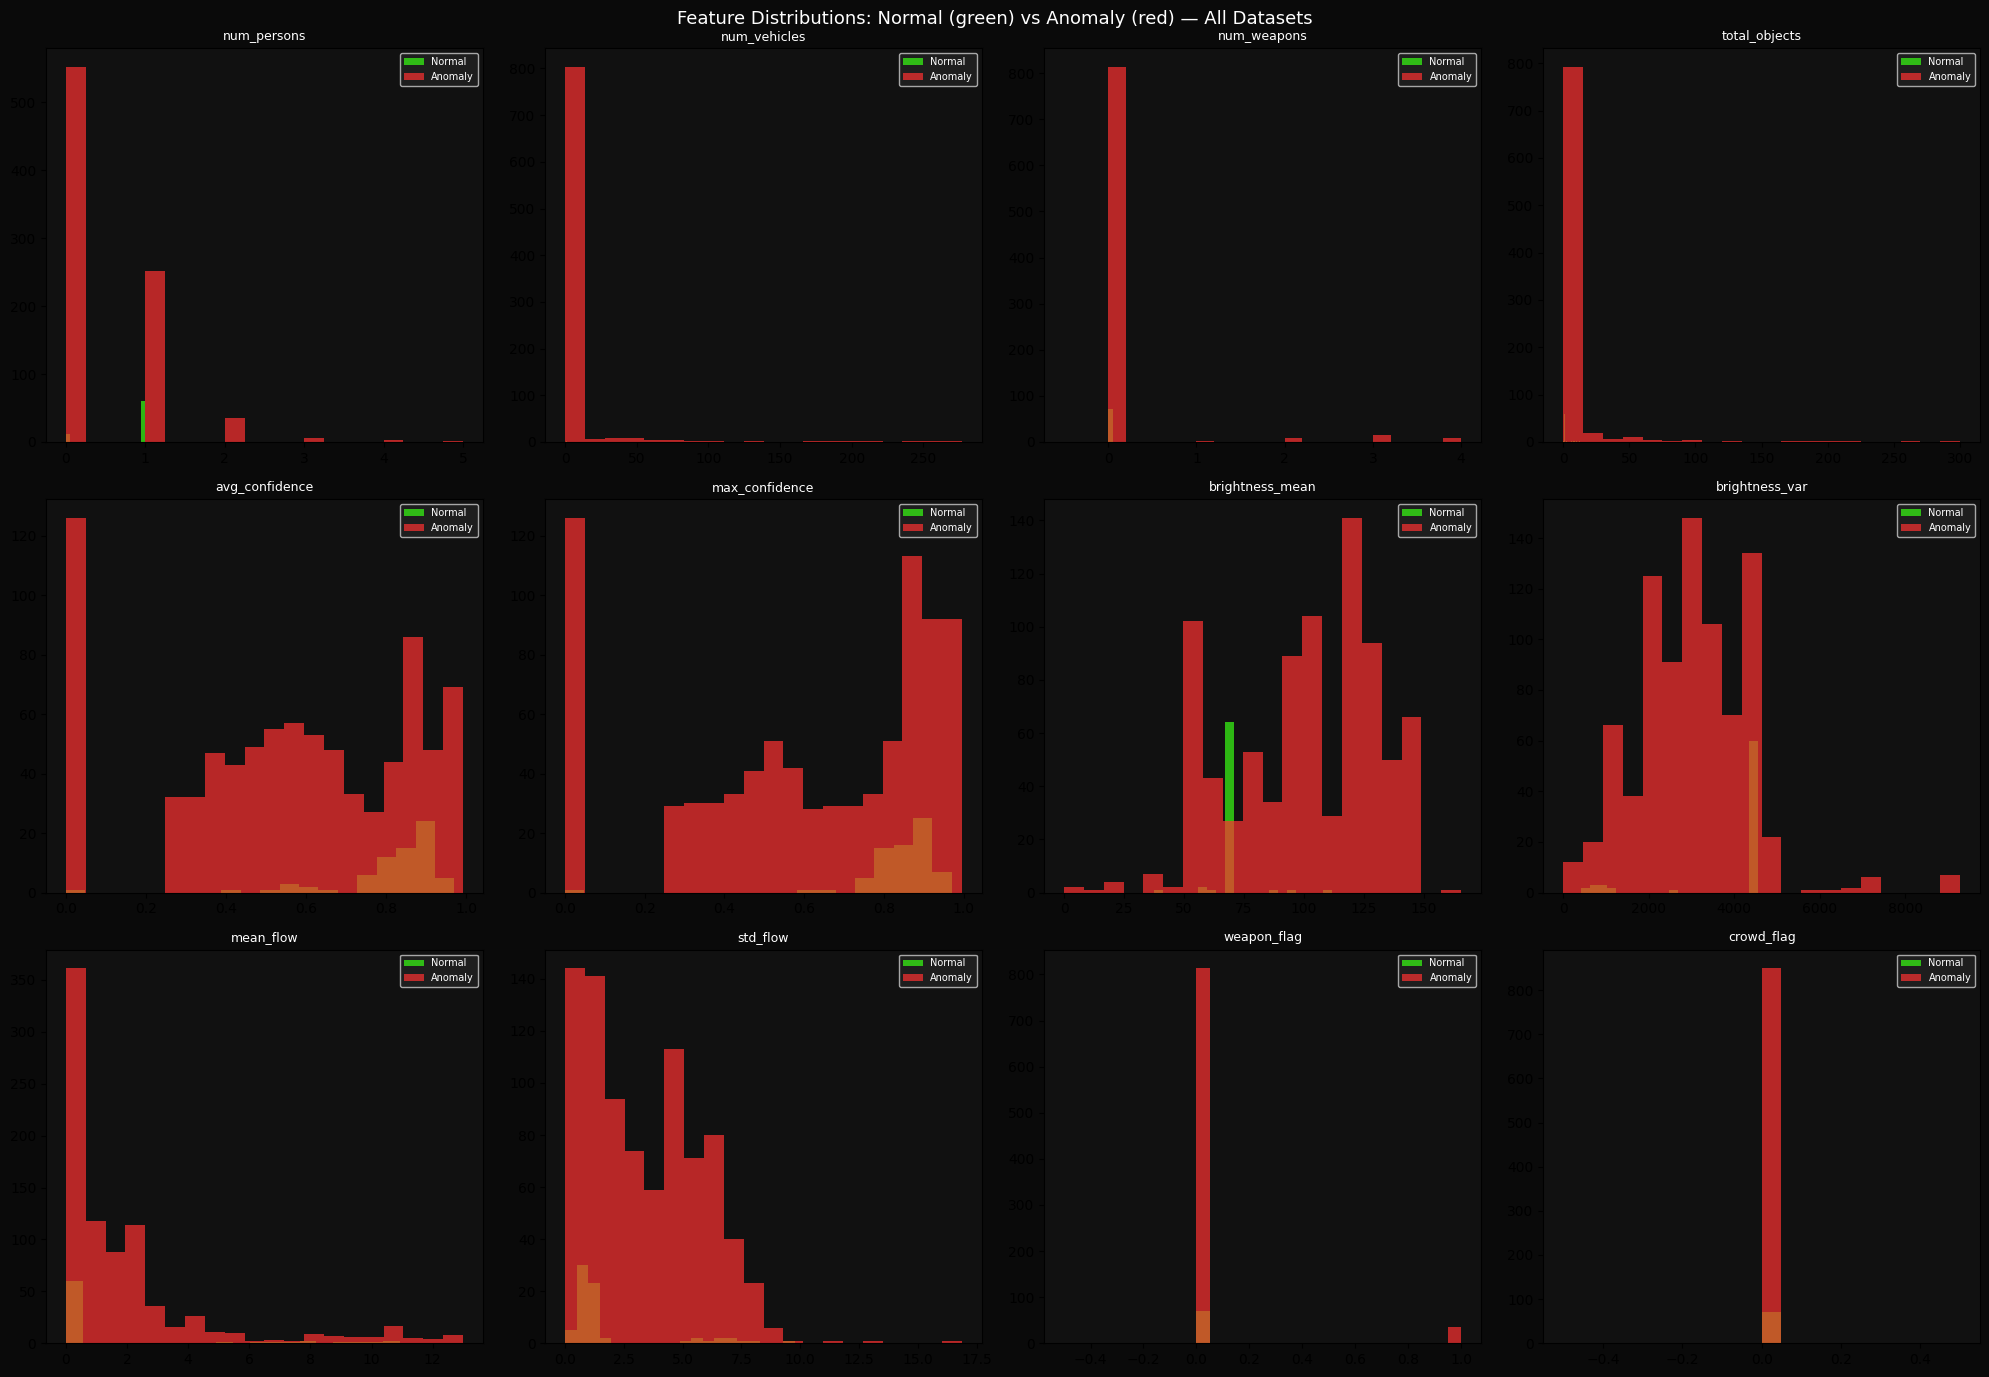

Saved → results/charts/feature_distributions.png


In [4]:
# ── Visualize feature distributions per source ────────────────────────────────
df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat['label']  = y
df_feat['source'] = sources

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('Feature Distributions: Normal (green) vs Anomaly (red) — All Datasets',
             color='white', fontsize=13)

for ax, feat in zip(axes.flat, FEATURE_NAMES):
    ax.set_facecolor('#111111')
    for lbl, color, name in [(0, '#39FF14', 'Normal'), (1, '#FF3131', 'Anomaly')]:
        data = df_feat[df_feat.label == lbl][feat]
        ax.hist(data, bins=20, alpha=0.7, color=color, label=name)
    ax.set_title(feat, color='white', fontsize=9)
    ax.legend(fontsize=7, facecolor='#222', labelcolor='white')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/charts/feature_distributions.png',
            dpi=120, facecolor='#0A0A0A')
plt.show()
print('Saved → results/charts/feature_distributions.png')

---
## STEP 3 — Train Ensemble Anomaly Detector

In [5]:
# ── Train/test split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42,
    stratify=y if (y==0).sum() > 1 and (y==1).sum() > 1 else None
)

X_normal = X_train[y_train == 0]   # Isolation Forest trains on normal only
from sklearn.utils import resample
X_normal_train  = X_train[y_train == 0]
X_anomaly_train = X_train[y_train == 1]
n_target = min(len(X_anomaly_train), len(X_normal_train) * 3)
X_anomaly_bal   = resample(X_anomaly_train, n_samples=n_target, random_state=42)
X_train_bal     = np.vstack([X_normal_train, X_anomaly_bal])
y_train_bal     = np.array([0]*len(X_normal_train) + [1]*len(X_anomaly_bal))
X_normal        = X_normal_train
print(f'Balanced: normal={len(X_normal_train)} anomaly={len(X_anomaly_bal)}')
print(f'Train: {len(X_train)}  (normal={( y_train==0).sum()}, anomaly={(y_train==1).sum()})')
print(f'Test : {len(X_test)}   (normal={(y_test==0).sum()},  anomaly={(y_test==1).sum()})')
print(f'\nNormal-only (for IF): {len(X_normal)}')



Balanced: normal=50 anomaly=150
Train: 644  (normal=50, anomaly=594)
Test : 276   (normal=21,  anomaly=255)

Normal-only (for IF): 50


In [6]:


detector = AnomalyDetector(contamination=0.10)
detector.fit(
    normal_features  = X_normal,
    labeled_features = X_train_bal,
    labels           = y_train_bal,
)
print('Ensemble trained ✓')

[AnomalyDetector] Fitting scaler on normal features …
[AnomalyDetector] Training Isolation Forest …
  Isolation Forest trained on 50 samples.
[AnomalyDetector] Training Random Forest …
  Random Forest trained on 200 samples.
Ensemble trained ✓


---
## STEP 4 — Evaluate on Each Dataset Separately

In [7]:
unique_sources = np.unique(sources)
eval_records   = []

print('── Per-Dataset Evaluation ──────────────────────────────────')
for src in unique_sources:
    mask = sources == src
    X_src, y_src = X[mask], y[mask]

    if len(np.unique(y_src)) < 2:
        print(f'  {src:<20}: only one class — skipping')
        continue

    scores = detector.predict_batch(X_src)
    preds  = (scores >= 0.5).astype(int)

    tp  = ((preds==1) & (y_src==1)).sum()
    fp  = ((preds==1) & (y_src==0)).sum()
    tn  = ((preds==0) & (y_src==0)).sum()
    fn  = ((preds==0) & (y_src==1)).sum()
    fpr = fp / (fp + tn) if (fp+tn) > 0 else 0
    acc = (tp+tn) / len(y_src)

    try: auc = roc_auc_score(y_src, scores)
    except: auc = 0.0

    eval_records.append({
        'source': src, 'n': len(y_src),
        'accuracy': round(acc, 3), 'fpr': round(fpr, 3), 'auc': round(auc, 3)
    })
    print(f'  {src:<20}: acc={acc:.3f}  fpr={fpr:.3f}  auc={auc:.3f}')

df_eval = pd.DataFrame(eval_records)
df_eval.to_csv(f'{RESULTS_DIR}/metrics/anomaly_per_dataset.csv', index=False)
print(f'\nSaved → {RESULTS_DIR}/metrics/anomaly_per_dataset.csv')

── Per-Dataset Evaluation ──────────────────────────────────
  DOTA                : acc=0.887  fpr=0.818  auc=0.967
  UCF-Abuse           : only one class — skipping
  UCF-Arrest          : only one class — skipping
  UCF-Arson           : only one class — skipping
  UCF-Assault         : only one class — skipping
  UCF-Burglary        : only one class — skipping
  UCF-Explosion       : only one class — skipping
  UCF-Fighting        : only one class — skipping
  UCF-NormalVideos    : only one class — skipping
  UCF-RoadAccidents   : only one class — skipping
  UCF-Robbery         : only one class — skipping
  UCF-Shooting        : only one class — skipping
  UCF-Shoplifting     : only one class — skipping
  UCF-Stealing        : only one class — skipping
  UCF-Vandalism       : only one class — skipping

Saved → ../results/metrics/anomaly_per_dataset.csv


── Overall Evaluation ──────────────────────────────────────

── Anomaly Detection Evaluation ──────────────────
  Accuracy:           0.978
  False Positive Rate:0.286  (target < 0.20)
  ROC-AUC:            0.990
              precision    recall  f1-score   support

      Normal       1.00      0.71      0.83        21
     Anomaly       0.98      1.00      0.99       255

    accuracy                           0.98       276
   macro avg       0.99      0.86      0.91       276
weighted avg       0.98      0.98      0.98       276



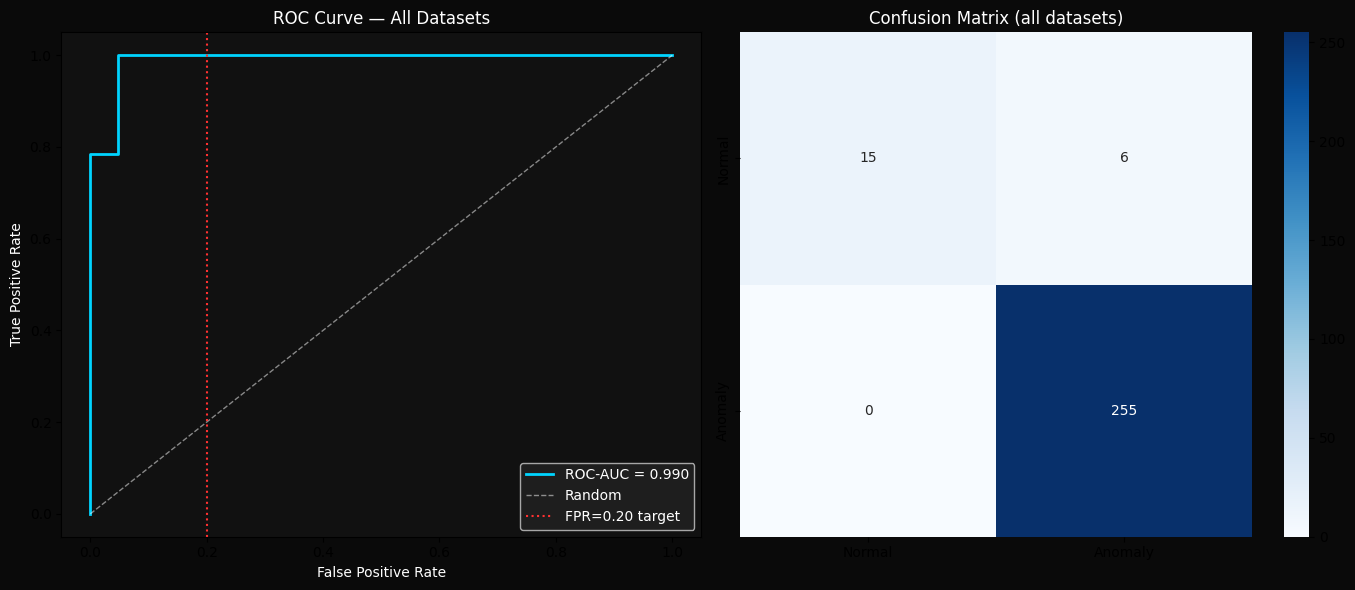

In [8]:

# ── Overall evaluation ────────────────────────────────────────────────────────
print('── Overall Evaluation ──────────────────────────────────────')
result = detector.evaluate(X_test, y_test, threshold=0.5)

# ROC curve
scores_test        = detector.predict_batch(X_test)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, scores_test)
auc_overall        = roc_auc_score(y_test, scores_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0A0A0A')

ax1.set_facecolor('#111111')
ax1.plot(fpr_arr, tpr_arr, color='#00D4FF', lw=2,
         label=f'ROC-AUC = {auc_overall:.3f}')
ax1.plot([0,1],[0,1], 'w--', lw=1, alpha=0.5, label='Random')
ax1.axvline(0.20, color='#FF3131', linestyle=':', label='FPR=0.20 target')
ax1.set_xlabel('False Positive Rate', color='white')
ax1.set_ylabel('True Positive Rate',  color='white')
ax1.set_title('ROC Curve — All Datasets', color='white')
ax1.legend(facecolor='#222', labelcolor='white')

cm = confusion_matrix(y_test, (scores_test >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
ax2.set_title('Confusion Matrix (all datasets)', color='white')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/charts/anomaly_roc_confusion.png',
            dpi=120, facecolor='#0A0A0A')
plt.show()




## STEP 5 — Anomaly Score Distribution by Dataset

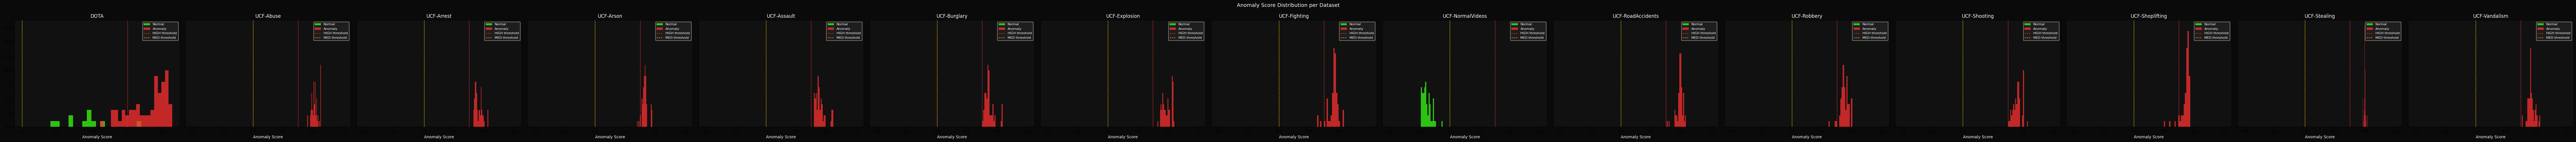

In [9]:
all_scores = detector.predict_batch(X)

df_scores = pd.DataFrame({
    'score':  all_scores,
    'label':  y,
    'source': sources
})

n_src = len(np.unique(sources))
fig, axes = plt.subplots(1, n_src, figsize=(6*n_src, 5), sharey=True)
if n_src == 1: axes = [axes]
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('Anomaly Score Distribution per Dataset', color='white', fontsize=13)

for ax, src in zip(axes, np.unique(sources)):
    ax.set_facecolor('#111111')
    df_src = df_scores[df_scores.source == src]
    ax.hist(df_src[df_src.label==0]['score'], bins=20, alpha=0.75,
            color='#39FF14', label='Normal')
    ax.hist(df_src[df_src.label==1]['score'], bins=20, alpha=0.75,
            color='#FF3131', label='Anomaly')
    ax.axvline(0.7, color='#FF3131', linestyle='--', lw=1, label='HIGH threshold')
    ax.axvline(0.4, color='#FFD600', linestyle='--', lw=1, label='MED threshold')
    ax.set_title(src, color='white')
    ax.set_xlabel('Anomaly Score', color='white')
    ax.legend(fontsize=8, facecolor='#222', labelcolor='white')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/charts/score_dist_per_dataset.png',
            dpi=120, facecolor='#0A0A0A')
plt.show()

## STEP 6 — Tune Threshold & Save Models

In [10]:
# Find the best threshold where FPR < 20%
best_thresh, best_fpr = 0.5, 1.0

for t in np.arange(0.3, 0.85, 0.05):
    preds_t = (scores_test >= t).astype(int)
    tn  = ((preds_t==0) & (y_test==0)).sum()
    fp  = ((preds_t==1) & (y_test==0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    if fpr < 0.20 and fpr < best_fpr:
        best_fpr    = fpr
        best_thresh = t

print(f'Optimal threshold : {best_thresh:.2f}')
print(f'Achieved FPR      : {best_fpr:.3f}  (target < 0.20)')

print('\n── Final evaluation at optimal threshold:')
detector.evaluate(X_test, y_test, threshold=best_thresh)

Optimal threshold : 0.75
Achieved FPR      : 0.000  (target < 0.20)

── Final evaluation at optimal threshold:

── Anomaly Detection Evaluation ──────────────────
  Accuracy:           0.685
  False Positive Rate:0.000  (target < 0.20)
  ROC-AUC:            0.990
              precision    recall  f1-score   support

      Normal       0.19      1.00      0.33        21
     Anomaly       1.00      0.66      0.79       255

    accuracy                           0.68       276
   macro avg       0.60      0.83      0.56       276
weighted avg       0.94      0.68      0.76       276



{'accuracy': 0.6847826086956522, 'fpr': 0.0, 'auc': 0.9897292250233426}

In [11]:
os.makedirs(MODELS_DIR, exist_ok=True)
detector.save(prefix=MODELS_DIR)

# Save combined pkl for convenience
joblib.dump(detector, f'{MODELS_DIR}/anomaly_ensemble.pkl')

# Save final metrics
final_metrics = pd.DataFrame([{
    'optimal_threshold': best_thresh,
    'fpr_at_threshold':  round(best_fpr, 4),
    'roc_auc':           round(auc_overall, 4),
    'accuracy':          round(result['accuracy'], 4),
    'total_samples':     len(X),
    'datasets_used':     ', '.join(np.unique(sources)),
}])
final_metrics.to_csv(f'{RESULTS_DIR}/metrics/anomaly_final_metrics.csv', index=False)

print('\nAll models saved:')
for f in glob.glob(f'{MODELS_DIR}/*.pkl'):
    print(f'  {f}')
print(f'\nMetrics saved → {RESULTS_DIR}/metrics/anomaly_final_metrics.csv')

[AnomalyDetector] Models saved to ../models/

All models saved:
  ../models\anomaly_ensemble.pkl
  ../models\isolation_forest.pkl
  ../models\random_forest.pkl
  ../models\scaler.pkl

Metrics saved → ../results/metrics/anomaly_final_metrics.csv
